# Analysis data survey

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Data loading + cleaning

In [2]:
# Row 0 and 1 contain data on information and can be dropped
# Row 2 contains only NaN values and therefore needs do be dropped as well (has a duration of 48 seconds)
df_values = pd.read_csv('data/qualtrics_values.csv')

df_clean_values = df_values.iloc[3:].copy()

df_clean_values.head()

,StartDate,EndDate,Status,IPAddress,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,RecipientLastName,...,baseline_4.9,baseline_5.9,baseline_6.9,split-rag_1.9,split-rag_2.9,split-rag_3.9,split-rag_4.9,split-rag_5.9,split-rag_6.9,Q32
3,2026-06-02 01:20:54,2026-06-02 02:07:49,0,194.13.133.3,100,2815,1,2026-06-02 02:07:50,R_8PDwnxI4hxF2Z8d,NaN,...,5,5,2,NaN,NaN,NaN,NaN,NaN,NaN,"Ik mis bronvermelding voor dit stukje: ""- Afwi..."
4,2026-06-02 03:06:02,2026-06-02 05:34:24,0,5.132.117.238,100,8901,1,2026-06-02 05:34:24,R_27PrvhprzXhPjX3,NaN,...,NaN,NaN,NaN,4,2,2,4,2,1,10.24 Omgevingswet gaat over een gedoogplicht ...
5,2026-06-02 05:08:11,2026-06-02 05:34:30,0,46.17.24.2,100,1578,1,2026-06-02 05:34:31,R_81d9VX4aBjG7dDJ,NaN,...,2,4,4,NaN,NaN,NaN,NaN,NaN,NaN,nvt
6,2026-06-04 02:27:26,2026-06-04 02:50:18,0,178.84.230.154,100,1371,1,2026-06-04 02:50:19,R_21aXhYhKby7DRt4,NaN,...,NaN,NaN,NaN,2,2,4,2,2,2,"Ik weet niet heel veel van bomenkap, maar dit ..."
7,2026-06-03 07:57:38,2026-06-04 04:09:32,0,84.80.81.172,100,72713,1,2026-06-04 04:09:33,R_2svK85YWUagVqoc,NaN,...,3,3,4,NaN,NaN,NaN,NaN,NaN,NaN,er is geen specifieke rechtspraak genoemd in h...


In [ ]:
# Identify all baseline and split-rag columns
baseline_cols = [col for col in df_clean_values.columns if col.startswith("baseline_")]
split_rag_cols = [col for col in df_clean_values.columns if col.startswith("split-rag_")]

# Convert the columns to numbers
for col in baseline_cols + split_rag_cols:
    df_clean_values[col] = pd.to_numeric(df_clean_values[col], errors='coerce')

# Matrix criteria labels 
criteria_labels = [
    "Logical coherence",
    "User intent",
    "Broad coverage",
    "Verfiability",
    "External consistency",
    "Normative justification",
]

b_means, s_means = [], []

# Loop through the 6 metrics and 10 cases
for i, label in enumerate(criteria_labels, start=1):
    
    # Case 1 is without dot (e.g., 'baseline_1'), Cases 2 t/m 10 are .1 t/m .9 (e.g., 'baseline_1.1')
    b_sel = [f'baseline_{i}'] + [f'baseline_{i}.{casus}' for casus in range(1, 10)]
    s_sel = [f'split-rag_{i}'] + [f'split-rag_{i}.{casus}' for casus in range(1, 10)]
    
    # Check if there are 10 cases found per metric)
    print(f"Metric {i}: {label:} -> Found cases: {len(b_sel)} (Baseline) | {len(s_sel)} (Split-RAG)")
    
    # Calculate mean
    b_means.append(df_clean_values[b_sel].mean().mean())
    s_means.append(df_clean_values[s_sel].mean().mean())

Metric 1: Logical coherence -> Found cases: 10 (Baseline) | 10 (Split-RAG)
Metric 2: User intent -> Found cases: 10 (Baseline) | 10 (Split-RAG)
Metric 3: Broad coverage -> Found cases: 10 (Baseline) | 10 (Split-RAG)
Metric 4: Verfiability -> Found cases: 10 (Baseline) | 10 (Split-RAG)
Metric 5: External consistency -> Found cases: 10 (Baseline) | 10 (Split-RAG)
Metric 6: Normative justification -> Found cases: 10 (Baseline) | 10 (Split-RAG)


In [ ]:
 # Metric summary table
summary_table = pd.DataFrame(
    {"Evaluation values": criteria_labels,
     "RAG Baseline (Mean)": b_means,
     "Split-RAG (Mean)": s_means,}
).round(2)

print(summary_table.to_string(index=False)) 

      Evaluation values  RAG Baseline (Mean)  Split-RAG (Mean)
      Logical coherence                 3.83              3.40
            User intent                 3.87              3.28
         Broad coverage                 2.77              2.35
           Verfiability                 3.07              3.40
   External consistency                 3.08              3.02
Normative justification                 2.92              1.97


## Visualisation for matrix results

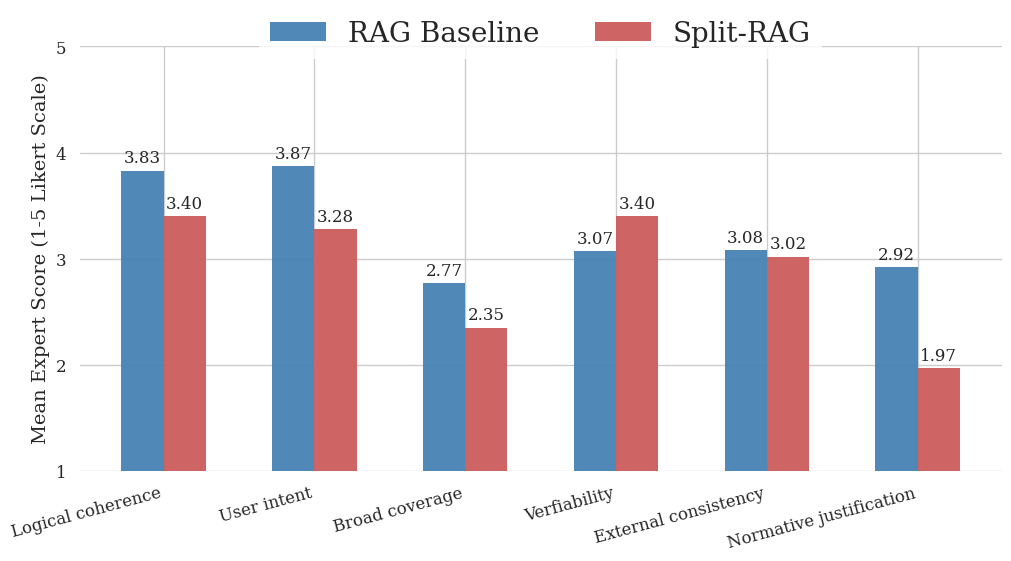

In [ ]:
# Theme
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,          
    'axes.labelsize': 14,      
    'xtick.labelsize': 12,    
    'ytick.labelsize': 12      
})

# Define configurations 
labels = summary_table["Evaluation values"].tolist()

# Extract the expert scores from summary table
system_scores = {
    'RAG Baseline': summary_table["RAG Baseline (Mean)"].tolist(),
    'Split-RAG': summary_table["Split-RAG (Mean)"].tolist(),
}

x = np.arange(len(labels))  
width = 0.28 
multiplier = 0

# Color palette 
colors = ['#4682B4', '#CD5C5C']

fig, ax = plt.subplots(figsize=(10, 5.5), layout='constrained')

# Dynamic bar generation 
for (system_name, scores), color in zip(system_scores.items(), colors):
    offset = width * multiplier
    rects = ax.bar(x + offset, scores, width, label=system_name, color=color, edgecolor='none', alpha=0.95)
    
    # Add micro-labels on top of bars
    ax.bar_label(rects, padding=3, fmt='%.2f', fontsize=12)
    multiplier += 1

# Layout styling and labels
ax.set_ylabel('Mean Expert Score (1-5 Likert Scale)')
ax.set_xticks(x + (width * 0.5))
ax.set_xticklabels(labels, rotation=15, ha='right') 

# Legend
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=2, frameon=True, facecolor='white', edgecolor='none', prop={'size': 20})

# Likert scale goes from 1 to 5
ax.set_ylim(1.0, 5.0)
ax.set_yticks([1.0, 2.0, 3.0, 4.0, 5.0])

# Clean chart borders
sns.despine(left=True, bottom=True)

# Save graph 
plt.savefig('results/sq3_expert_validation_results.png', dpi=300, bbox_inches='tight')
plt.show()

## Randomization proof

In [77]:
# build mapping per respondent using ResponseId
randomization_mapping = []

for index, row in df_clean_values.iterrows():
    respondent_id = row.get('ResponseId', f"Respondent_{index}")
    respondent_cases = {"Respondent": respondent_id}
    
    # check system assignment for each of the 10 cases
    for case_num in range(1, 11):
        if case_num == 1:
            b_col = "baseline_1"
            s_col = "split-rag_1"
        else:
            b_col = f"baseline_1.{case_num - 1}"
            s_col = f"split-rag_1.{case_num - 1}"
        
        # identify which column contains experimental data
        if pd.notna(row[b_col]):
            respondent_cases[f"Case {case_num}"] = "Baseline"
        elif pd.notna(row[s_col]):
            respondent_cases[f"Case {case_num}"] = "Split-RAG"
        else:
            respondent_cases[f"Case {case_num}"] = "Missing"
            
    randomization_mapping.append(respondent_cases)

# convert to tracking dataframe
randomization_matrix = pd.DataFrame(randomization_mapping)
randomization_matrix

,Respondent,Case 1,Case 2,Case 3,Case 4,Case 5,Case 6,Case 7,Case 8,Case 9,Case 10
0,R_8PDwnxI4hxF2Z8d,Split-RAG,Split-RAG,Split-RAG,Baseline,Split-RAG,Split-RAG,Baseline,Baseline,Baseline,Baseline
1,R_27PrvhprzXhPjX3,Split-RAG,Split-RAG,Baseline,Split-RAG,Baseline,Baseline,Baseline,Baseline,Split-RAG,Split-RAG
2,R_81d9VX4aBjG7dDJ,Baseline,Baseline,Baseline,Baseline,Baseline,Split-RAG,Split-RAG,Split-RAG,Baseline,Baseline
3,R_21aXhYhKby7DRt4,Split-RAG,Split-RAG,Baseline,Baseline,Split-RAG,Split-RAG,Baseline,Baseline,Baseline,Split-RAG
4,R_2svK85YWUagVqoc,Baseline,Baseline,Split-RAG,Split-RAG,Split-RAG,Baseline,Split-RAG,Split-RAG,Split-RAG,Baseline


## Qualitative feedback per model

In [ ]:
# build qualitative feedback mapping per respondent and case
feedback_records = []

for index, row in df_clean_values.iterrows():
    respondent_id = row.get('ResponseId', f"Respondent_{index}")
    
    # map cases 1-10 to Qualtrics text columns Q23-Q32
    for case_idx in range(1, 11):
        q_column = f"Q{22 + case_idx}"
        feedback_text = row.get(q_column)
        
        # map system column names based on column structure
        if case_idx == 1:
            b_col = "baseline_1"
            s_col = "split-rag_1"
        else:
            b_col = f"baseline_1.{case_idx - 1}"
            s_col = f"split-rag_1.{case_idx - 1}"
            
        # check system assignment for current case
        if pd.notna(row[b_col]):
            assigned_system = "Baseline"
        elif pd.notna(row[s_col]):
            assigned_system = "Split-RAG"
        else:
            assigned_system = "Unknown"
            
        # append record only if respondent provided feedback
        if pd.notna(feedback_text) and str(feedback_text).strip() != "":
            feedback_records.append({
                "Respondent": respondent_id,
                "Case": f"Case {case_idx}",
                "System": assigned_system,
                "Feedback": str(feedback_text).strip()
            })

# compile data into overview dataframe
df_feedback_overview = pd.DataFrame(feedback_records)

# save dataframe as csv 
df_feedback_overview.to_csv('sq3_expert_feedback.csv', index=False)

# display output table
pd.set_option('display.max_colwidth', None)
df_feedback_overview

,Respondent,Case,System,Feedback
0,R_8PDwnxI4hxF2Z8d,Case 1,Split-RAG,"Het antwoord klopt, maar is meer een soort juridisch kader en niet per se waarderend."
1,R_8PDwnxI4hxF2Z8d,Case 2,Split-RAG,"Het antwoord gaat in op de omgevingswet, wat logisch lijkt omdat de casus misschien over het omgevingsrecht gaat. Alleen in een geval als deze is het handiger om gebruik te maken van de Algemene wet bestuursrecht, daarin staat een exact artikel over tijdige indiening van een bezwaarschrift."
2,R_8PDwnxI4hxF2Z8d,Case 3,Split-RAG,In dit geval wordt nog een wabo (oud recht) artikel benoemd terwijl de omgevingswet nu van kracht is. Het wabo artikel kan wellicht toepasselijk zijn als er sprake is van een oude vergunning (van voor 1 januari 2024) in dat geval zal ook overgangsrecht benoemd moeten worden.
3,R_8PDwnxI4hxF2Z8d,Case 4,Baseline,"De bezwaarmaker lijkt te doelen op het gelijkheidsbeginsel, hier moet dan nog even kort op in worden gegaan."
4,R_8PDwnxI4hxF2Z8d,Case 5,Split-RAG,Duidelijke tekst mist alleen meer context
5,R_8PDwnxI4hxF2Z8d,Case 6,Split-RAG,Ik mis hier de eventuele welstandsnormen.
6,R_8PDwnxI4hxF2Z8d,Case 7,Baseline,hier worden de welstandsnormen wel benoemd
7,R_8PDwnxI4hxF2Z8d,Case 8,Baseline,netjes
8,R_8PDwnxI4hxF2Z8d,Case 9,Baseline,De uitspraken zijn heel oud en er is al een nieuw systeem (omgevingswet)
9,R_8PDwnxI4hxF2Z8d,Case 10,Baseline,"Ik mis bronvermelding voor dit stukje: ""- Afwijken van exacte leeftijd of dikte van de oorspronkelijke boom:"""


### Baseline feedback

In [81]:
baseline_feedback = []

for index, row in df_clean_values.iterrows():
    respondent_id = row.get('ResponseId', f"Respondent_{index}")
    
    for case_idx in range(1, 11):
        q_column = f"Q{22 + case_idx}"
        feedback_text = row.get(q_column)
        
        # Determine baseline column name
        b_col = "baseline_1" if case_idx == 1 else f"baseline_1.{case_idx - 1}"
            
        # Check if the baseline system was active and feedback exists
        if pd.notna(row[b_col]) and pd.notna(feedback_text):
            clean_text = str(feedback_text).strip()
            # Filter out generic 'not applicable' answers to keep data high-quality
            if clean_text != "" and clean_text.lower() != "nvt":
                baseline_feedback.append({
                    "Respondent": respondent_id,
                    "Case": f"Case {case_idx}",
                    "System": "Baseline",
                    "Feedback": clean_text
                })

# Compile and save baseline feedback
df_baseline_feedback = pd.DataFrame(baseline_feedback)
df_baseline_feedback.to_csv('sq3_baseline_expert_feedback.csv', index=False)

# Display table
pd.set_option('display.max_colwidth', None)
df_baseline_feedback

,Respondent,Case,System,Feedback
0,R_8PDwnxI4hxF2Z8d,Case 4,Baseline,"De bezwaarmaker lijkt te doelen op het gelijkheidsbeginsel, hier moet dan nog even kort op in worden gegaan."
1,R_8PDwnxI4hxF2Z8d,Case 7,Baseline,hier worden de welstandsnormen wel benoemd
2,R_8PDwnxI4hxF2Z8d,Case 8,Baseline,netjes
3,R_8PDwnxI4hxF2Z8d,Case 9,Baseline,De uitspraken zijn heel oud en er is al een nieuw systeem (omgevingswet)
4,R_8PDwnxI4hxF2Z8d,Case 10,Baseline,"Ik mis bronvermelding voor dit stukje: ""- Afwijken van exacte leeftijd of dikte van de oorspronkelijke boom:"""
5,R_27PrvhprzXhPjX3,Case 3,Baseline,"5:40, tweede lid, onder b van de Omgevingswet geeft de intrekkingsbevoegdheid als er een jaar geen gebruik is gemaakt van de vergunning. De verwijzing naar 5:40, tweede lid onder d is dus onjuist."
6,R_27PrvhprzXhPjX3,Case 5,Baseline,"Inhoudelijk is AI volledig de mist ingegaan. Wabo geldt niet meer, daar is de Omgevingswet voor in de plaats getreden. Bij een binnenplanse afwijking is zijn de ruimtelijke effecten al gewogen bij het creëeren van de afwijkingsmogelijkheid. De goede ruimtelijke ordening wordt niet bij de beoordeling van de vergunningverlening gewogen, daargelaten dat dat een verouderde termijn uit het Wabo tijdperk is."
7,R_27PrvhprzXhPjX3,Case 6,Baseline,Denk dat hier ook wordt gedoeld om de evident privaatrechtelijke belemmering. AI lijkt niet in staat te zijn relevante informatie van buiten de vraagstelling te betrekken.
8,R_27PrvhprzXhPjX3,Case 7,Baseline,"2.10 onder d van de Omgevingswet bestaat niet. Artikel 2.10 van de Omgevingswet gaat niet over de welstandsexcessen. Sowieso moet AI eerst beoordelen of de panelen vergunningsvrij gerealiseerd kunnen worden. Zo nee, moet beoordeeld worden of een vergunning verleend kan worden. AI gaat veel te kort door de bocht. Daarnaast ga ik ervan uit dat het gewone zonnepanelen zijn. Die vormen zelden een welstandsexces, zeker als ze geplaatst worden op het achtererf (wat we niet weten)."
9,R_27PrvhprzXhPjX3,Case 8,Baseline,"Juiste artikel, had nog iets specifieker kunnen zijn door te verwijzen naar sub c."


### Split-RAG feedback

In [82]:
splitrag_feedback = []

for index, row in df_clean_values.iterrows():
    respondent_id = row.get('ResponseId', f"Respondent_{index}")
    
    for case_idx in range(1, 11):
        q_column = f"Q{22 + case_idx}"
        feedback_text = row.get(q_column)
        
        # Determine split-rag column name
        s_col = "split-rag_1" if case_idx == 1 else f"split-rag_1.{case_idx - 1}"
            
        # Check if the split-rag system was active and feedback exists
        if pd.notna(row[s_col]) and pd.notna(feedback_text):
            clean_text = str(feedback_text).strip()
            # Filter out generic 'not applicable' answers to keep data high-quality
            if clean_text != "" and clean_text.lower() != "nvt":
                splitrag_feedback.append({
                    "Respondent": respondent_id,
                    "Case": f"Case {case_idx}",
                    "System": "Split-RAG",
                    "Feedback": clean_text
                })

# Compile and save split-rag feedback
df_splitrag_feedback = pd.DataFrame(splitrag_feedback)
df_splitrag_feedback.to_csv('sq3_splitrag_expert_feedback.csv', index=False)

# Display table
pd.set_option('display.max_colwidth', None)
df_splitrag_feedback

,Respondent,Case,System,Feedback
0,R_8PDwnxI4hxF2Z8d,Case 1,Split-RAG,"Het antwoord klopt, maar is meer een soort juridisch kader en niet per se waarderend."
1,R_8PDwnxI4hxF2Z8d,Case 2,Split-RAG,"Het antwoord gaat in op de omgevingswet, wat logisch lijkt omdat de casus misschien over het omgevingsrecht gaat. Alleen in een geval als deze is het handiger om gebruik te maken van de Algemene wet bestuursrecht, daarin staat een exact artikel over tijdige indiening van een bezwaarschrift."
2,R_8PDwnxI4hxF2Z8d,Case 3,Split-RAG,In dit geval wordt nog een wabo (oud recht) artikel benoemd terwijl de omgevingswet nu van kracht is. Het wabo artikel kan wellicht toepasselijk zijn als er sprake is van een oude vergunning (van voor 1 januari 2024) in dat geval zal ook overgangsrecht benoemd moeten worden.
3,R_8PDwnxI4hxF2Z8d,Case 5,Split-RAG,Duidelijke tekst mist alleen meer context
4,R_8PDwnxI4hxF2Z8d,Case 6,Split-RAG,Ik mis hier de eventuele welstandsnormen.
5,R_27PrvhprzXhPjX3,Case 1,Split-RAG,"Het antwoord haalt de regels over rijksmonumenten erbij, terwijl het over een gemeentelijk monument gaat. Ook noemt het antwoord niet de mogelijkheid van een BOPA"
6,R_27PrvhprzXhPjX3,Case 2,Split-RAG,16.98 van de Omgevingswet is niet van toepassing. Ik mis een verwijzing naar 6:9 Awb.
7,R_27PrvhprzXhPjX3,Case 4,Split-RAG,"Wabo geldt niet meer, dus had niet genoemd moeten worden. Verwijzing naar 10.18 Ow is ook niet relevant. AI had eruit moeten halen dat het gelijkheidsbeginsel speelt en daarover rechtspraak moeten zoeken."
8,R_27PrvhprzXhPjX3,Case 9,Split-RAG,"Hier ook weer: 2.10, eerste lid, van de Wabo geldt niet meer. Verwijzing naar de uitspraak van de Afdeling bestuursrechtspraak klopt wel, maar ik noemt eigenlijk een algemeen leerstuk. Het spitst zich weinig toe op de casus."
9,R_27PrvhprzXhPjX3,Case 10,Split-RAG,10.24 Omgevingswet gaat over een gedoogplicht en is niet relevant. 18.4a speelt hier niet. AI had moeten noemen wanneer een belangenvereniging belanghebbende is en in hoeverre het college de last zelf mag formuleren.
